<a href="https://colab.research.google.com/github/amanmd07/2520030190_ML/blob/master/skill/WEEK_2_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
import pandas as pd
import seaborn as sns

In [3]:
# California Housing Dataset
# Upload housing.csv to Google Colab before running this cell
from pandas import read_csv
df = read_csv("/content/housing (1).csv")
df.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
# Numerical vs Categorical features
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

print("Numerical Features:", list(numerical_features))
print("Categorical Features:", list(categorical_features))


Numerical Features: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']
Categorical Features: ['ocean_proximity']


In [5]:
# Select only numerical columns for correlation
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numerical_cols].corr()


In [6]:
# Print matrix to terminal
print("\n--- Correlation Matrix ---")
print(corr_matrix)


--- Correlation Matrix ---
                    longitude  latitude  housing_median_age  total_rooms  \
longitude            1.000000 -0.924664           -0.108197     0.044568   
latitude            -0.924664  1.000000            0.011173    -0.036100   
housing_median_age  -0.108197  0.011173            1.000000    -0.361262   
total_rooms          0.044568 -0.036100           -0.361262     1.000000   
total_bedrooms       0.069608 -0.066983           -0.320451     0.930380   
population           0.099773 -0.108785           -0.296244     0.857126   
households           0.055310 -0.071035           -0.302916     0.918484   
median_income       -0.015176 -0.079809           -0.119034     0.198050   
median_house_value  -0.045967 -0.144160            0.105623     0.134153   

                    total_bedrooms  population  households  median_income  \
longitude                 0.069608    0.099773    0.055310      -0.015176   
latitude                 -0.066983   -0.108785   -0.07103

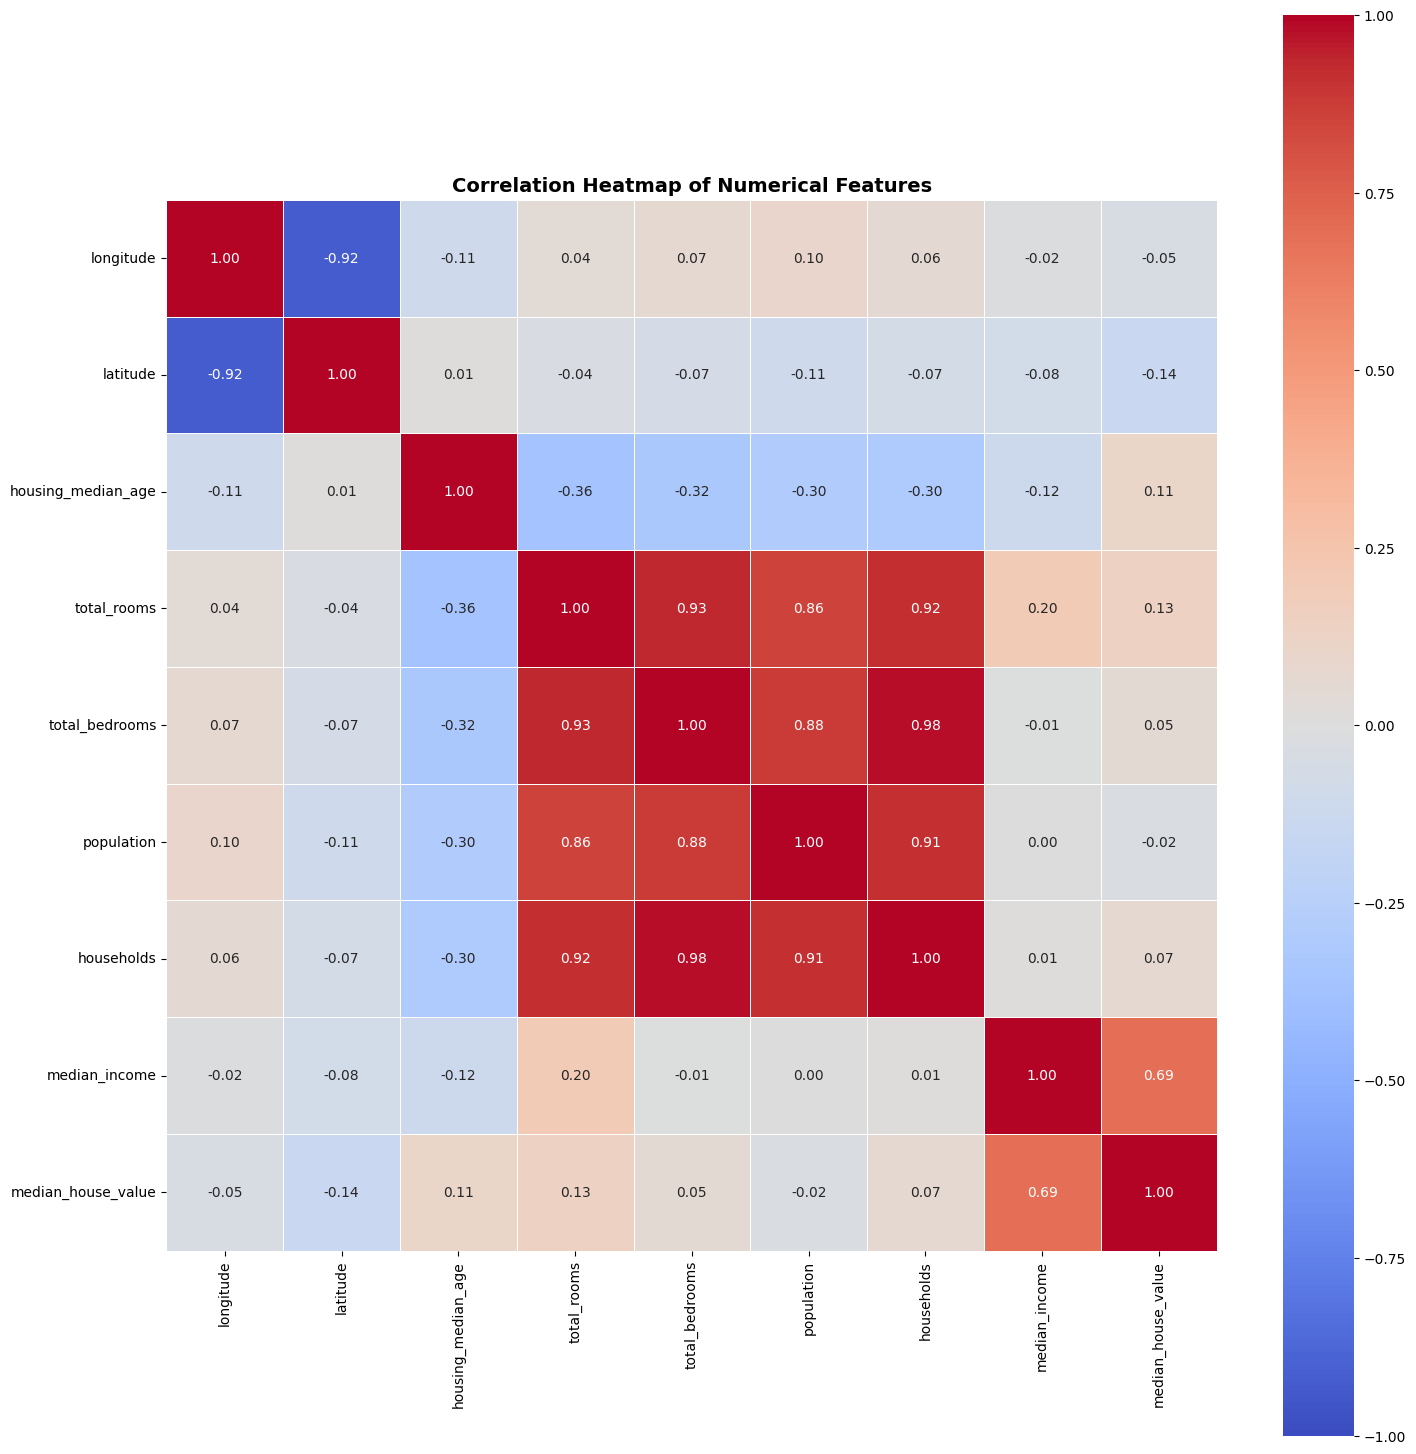

In [7]:
# Create Heatmap
import matplotlib.pyplot as plt
plt.figure(figsize=(15,15))
sns.heatmap(
corr_matrix,
annot=True,
cmap="coolwarm",
fmt=".2f",
vmin=-1,
vmax=1,
square=True,
linewidths=0.5
)
plt.title("Correlation Heatmap of Numerical Features", fontsize=14, fontweight="bold")
plt.tight_layout()

In [8]:

# Export Heatmap
import os
output_dir = "/content/"
heatmap_path = os.path.join(output_dir, "correlation_heatmap.png")
plt.savefig(heatmap_path, dpi=300)
plt.close()
print(f"Exported heatmap to: {heatmap_path}")

Exported heatmap to: /content/correlation_heatmap.png


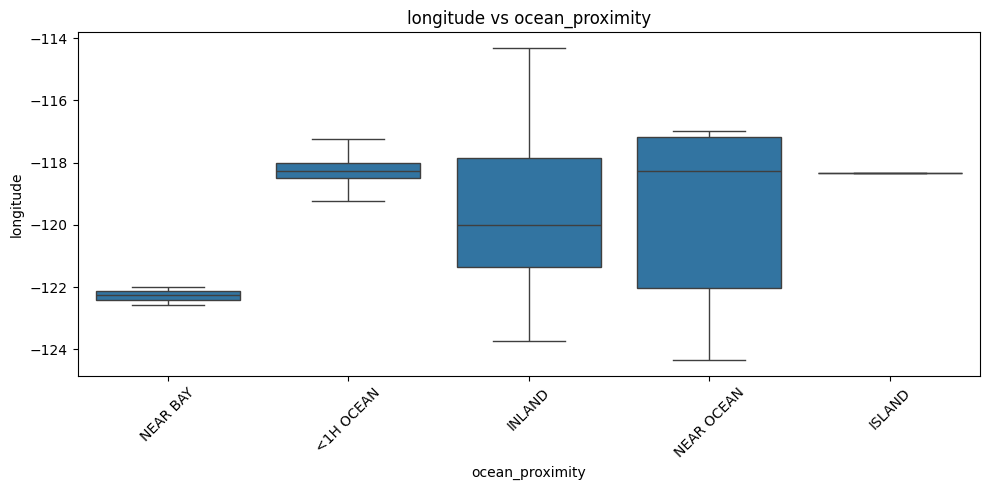

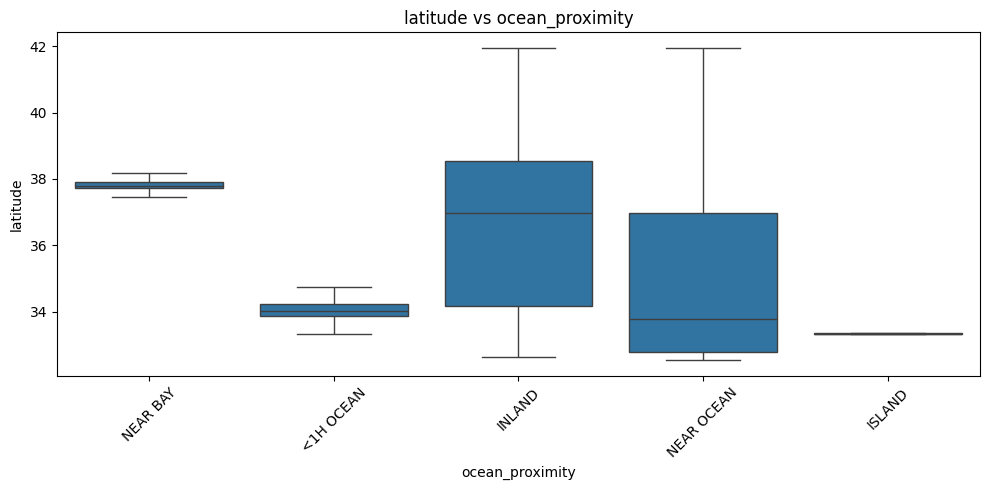

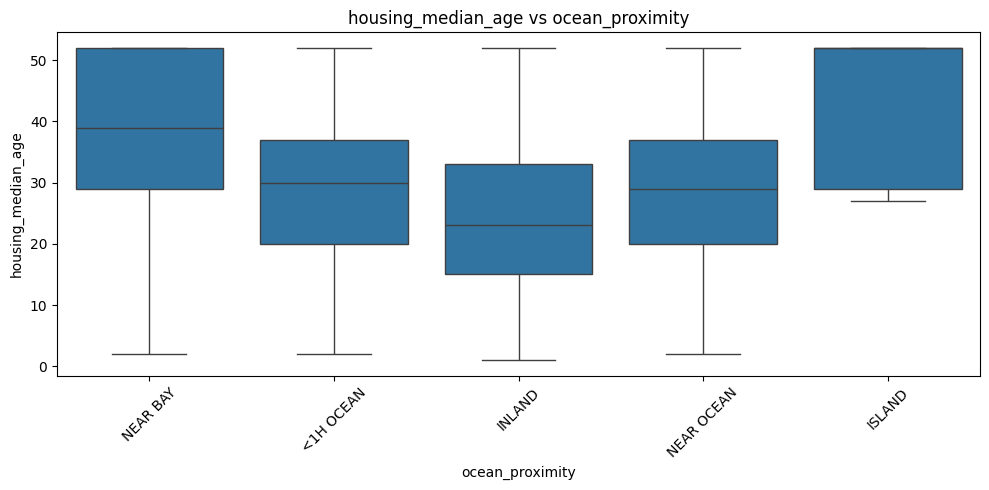

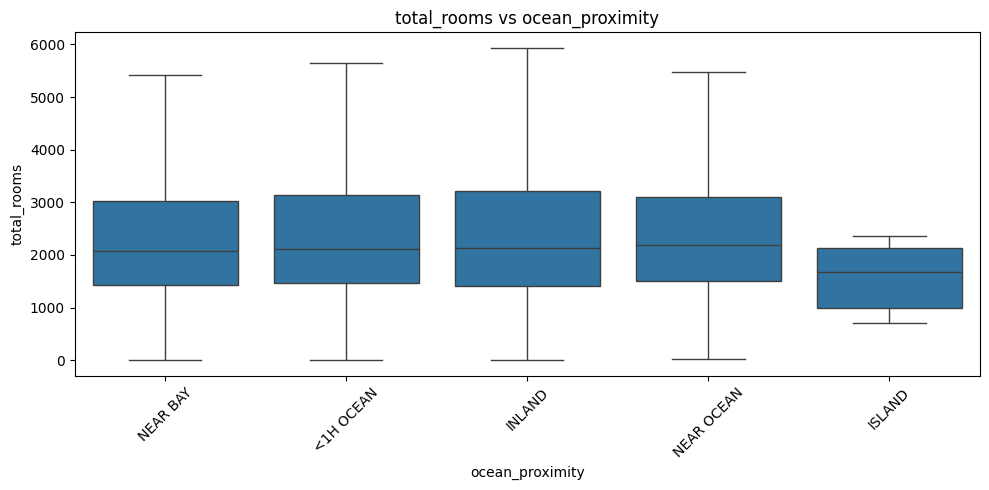

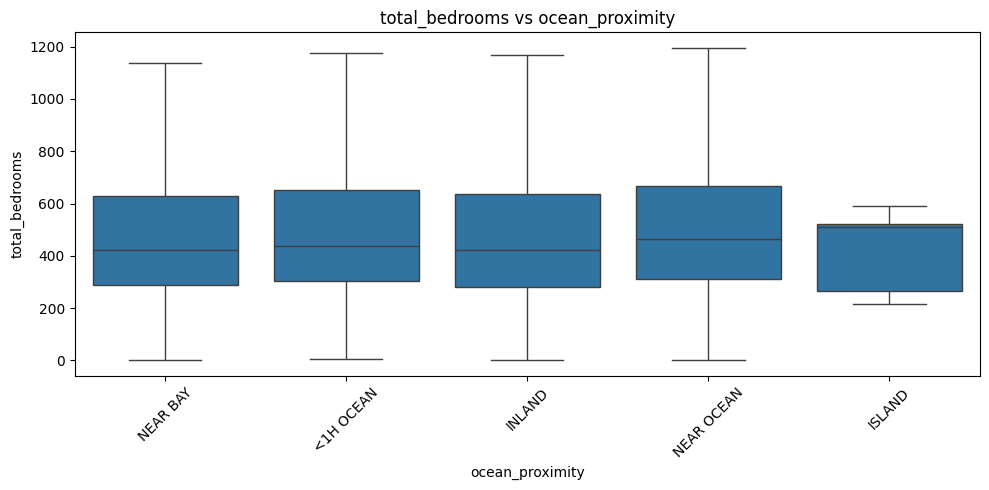

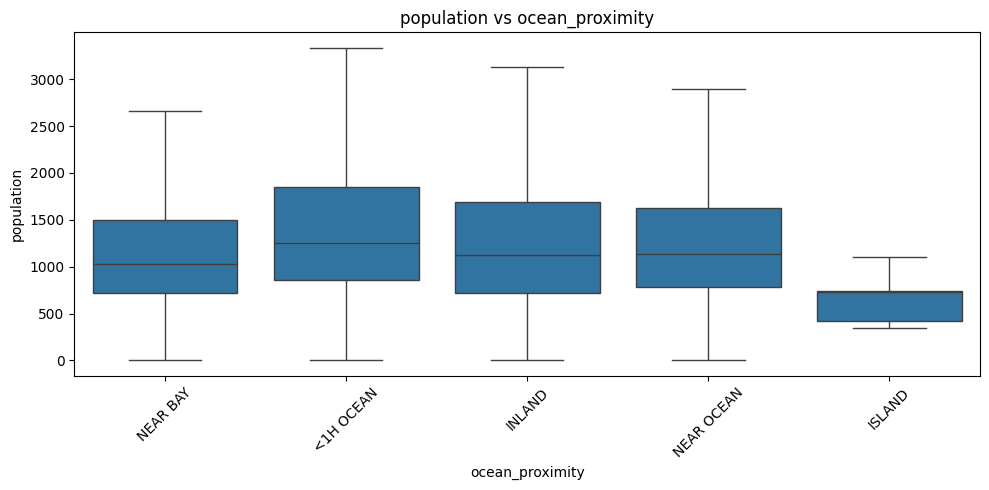

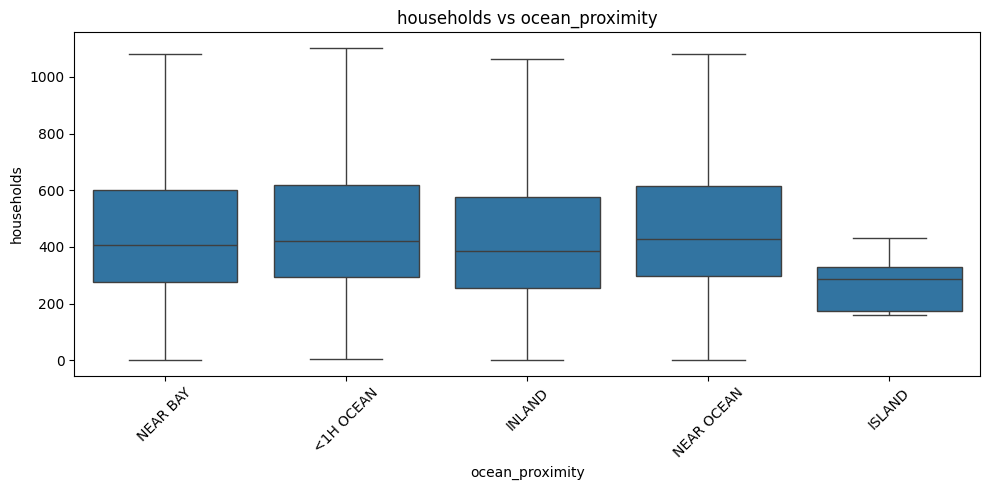

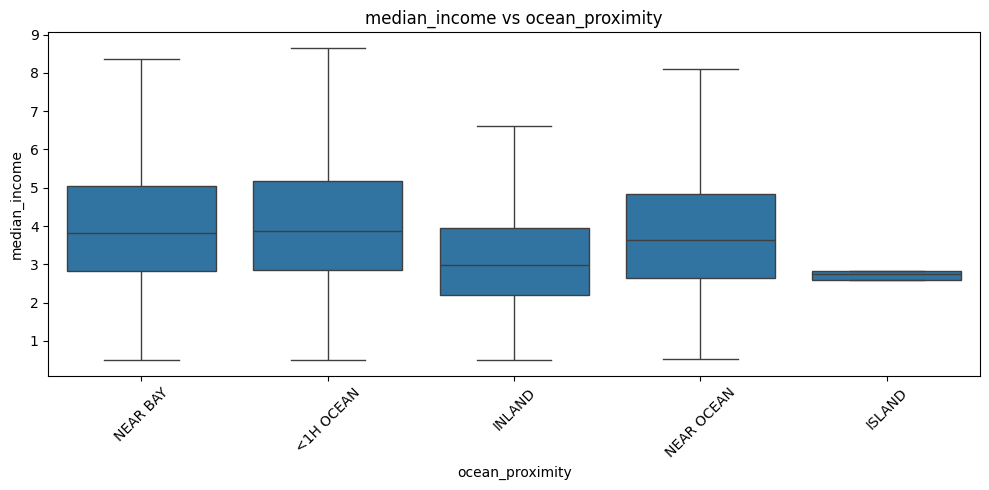

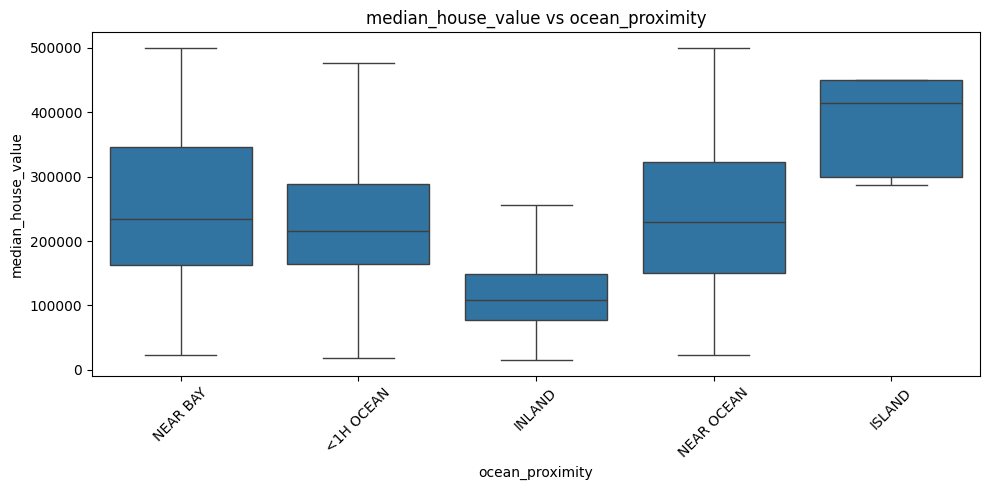

In [9]:
# -------------------------------------------------------------
# 3. Produce Boxplots: Numerical Features vs Ocean Proximity
# -------------------------------------------------------------

target_col = "ocean_proximity"

for col in numerical_cols:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df, x=target_col, y=col, showfliers=False)
    plt.title(f"{col} vs {target_col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


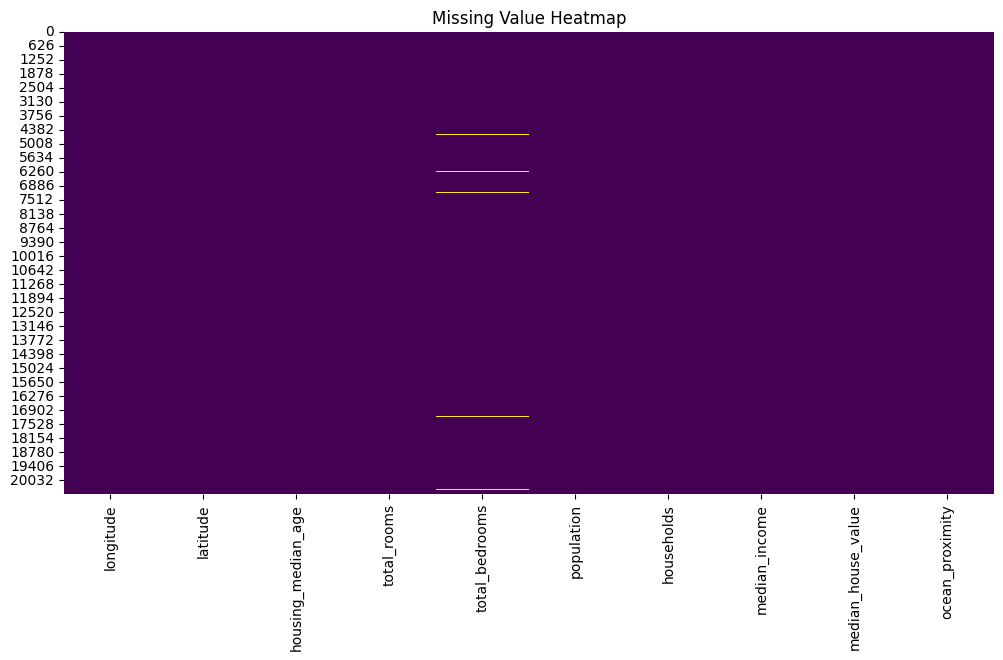

In [10]:
import matplotlib.pyplot as plt
fig1=plt.figure(figsize=(12,6))

sns.heatmap(
         df.isnull(),
        cbar=False,
         cmap="viridis"
)

plt.title("Missing Value Heatmap")

plt.show()

### **Observation**

The missing value heatmap is used to identify missing values in the California Housing dataset. Any visible gaps or different color patterns indicate columns that contain missing values and may require preprocessing.


<Figure size 1500x800 with 0 Axes>

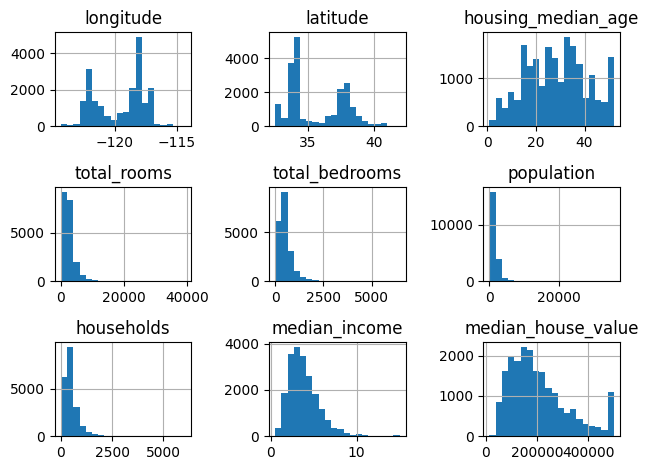

In [11]:
features = [
    "longitude",
    "latitude",
    "housing_median_age",
    "total_rooms",
    "total_bedrooms",
    "population",
    "households",
    "median_income",
    "median_house_value"
]

fig2 = plt.figure(figsize=(15, 8))
df[features].hist(bins=20)
plt.tight_layout()
plt.show()


# Observations:

### **1. Longitude and Latitude**
- These features show the geographical distribution of housing districts.
- Different values represent different locations in California.

### **2. Housing Median Age**
- This feature shows the age distribution of houses.
- Most values are concentrated within a moderate range.

### **3. Total Rooms and Total Bedrooms**
- These features are generally right-skewed.
- Some districts contain unusually large numbers of rooms and bedrooms.

### **4. Population and Households**
- These features show how population and households vary across districts.
- Higher values indicate more populated areas.

### **5. Median Income**
- Median income is an important economic feature.
- It can have a strong relationship with house values.

### **6. Median House Value**
- This is the main housing value feature.
- Its distribution helps us understand the variation in house prices.


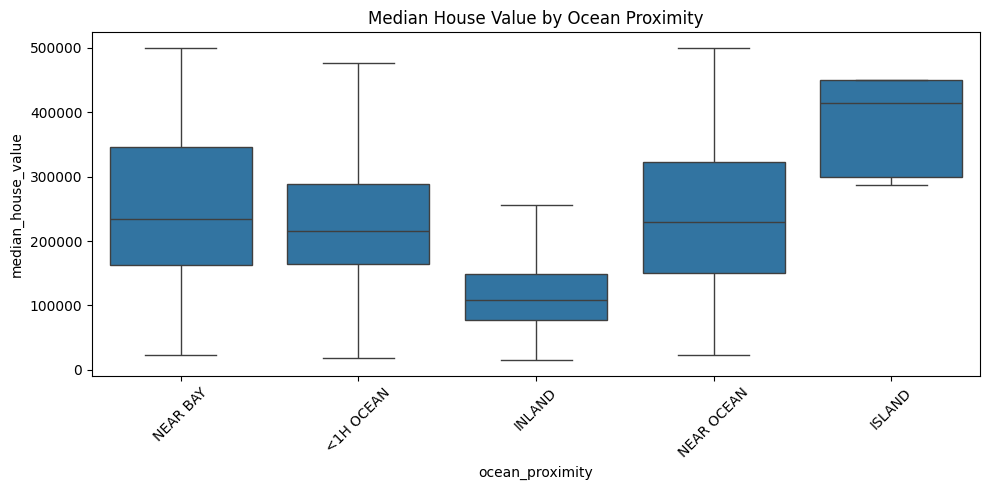

In [12]:
# Median house value by ocean proximity

fig3 = plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="ocean_proximity",
    y="median_house_value",
    showfliers=False
)

plt.title("Median House Value by Ocean Proximity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


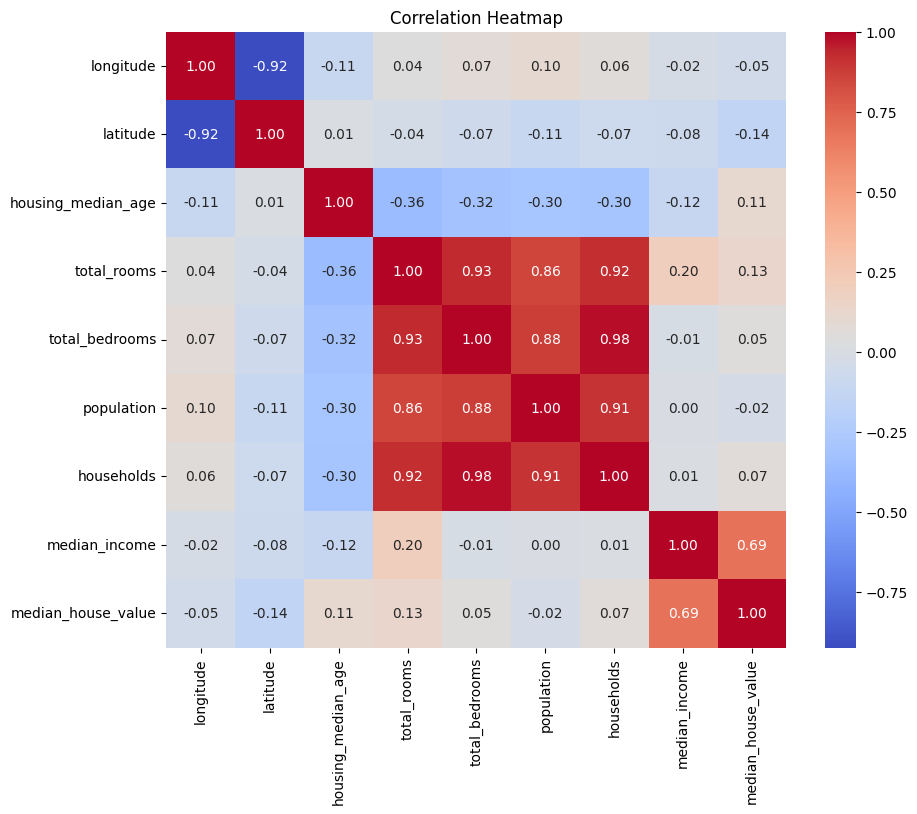

In [13]:
#Corelation Heatmap

fig5= plt.figure(figsize=(10,8))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

# Correlation Heatmap

To identify the relationship among numerical housing features and understand which variables are positively or negatively correlated.

A correlation heatmap visualizes the Pearson correlation coefficient between numerical features.

- A value close to +1 indicates a strong positive relationship.
- A value close to -1 indicates a strong negative relationship.
- A value close to 0 indicates a weak linear relationship.

This helps us understand relationships between features such as median income, total rooms, population, and median house value.


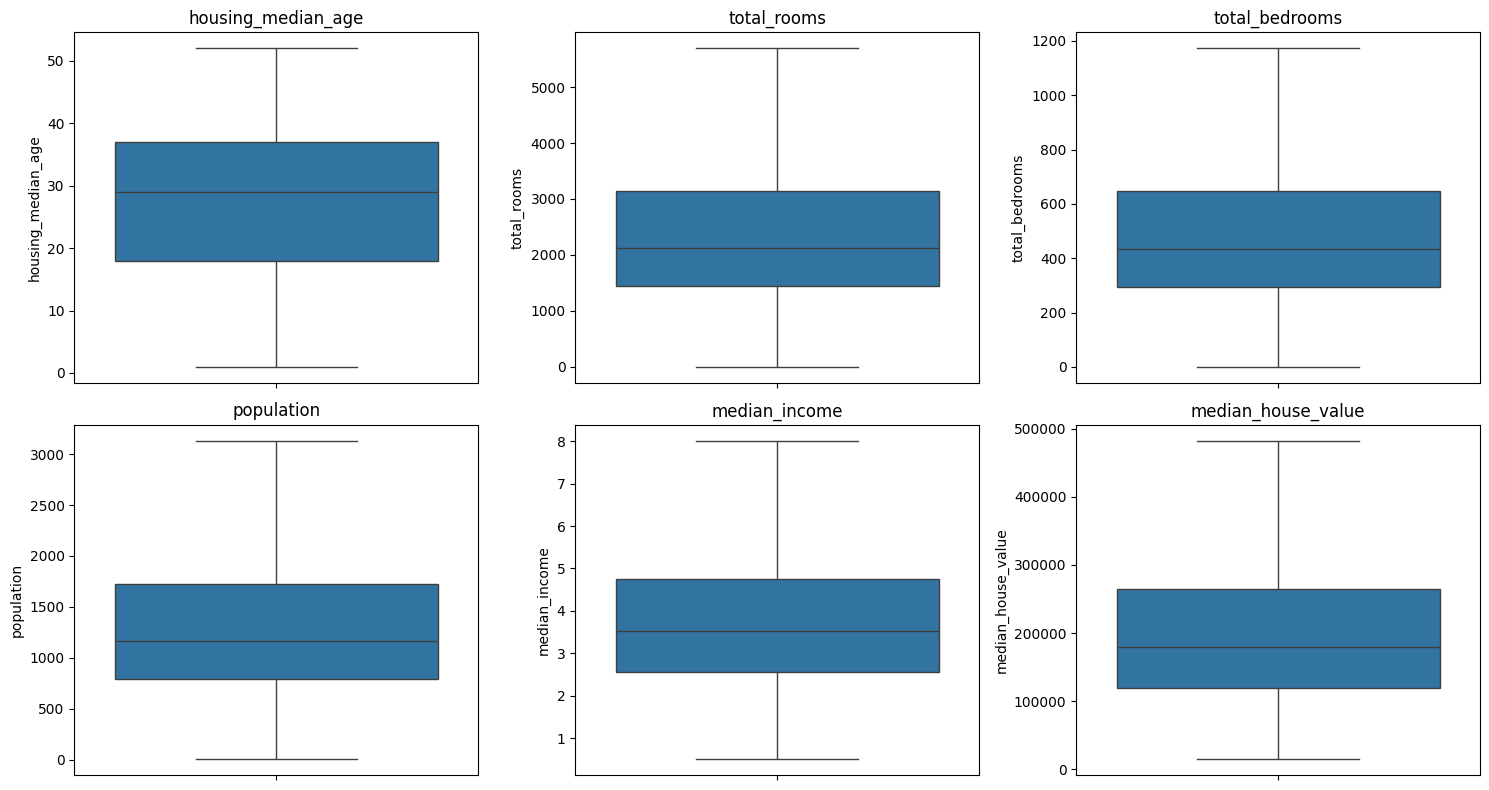

In [14]:
# Clean boxplots for numerical housing features
# Separate plots are used because the features have very different scales.

numerical_columns = [
    "housing_median_age",
    "total_rooms",
    "total_bedrooms",
    "population",
    "median_income",
    "median_house_value"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    sns.boxplot(y=df[col], ax=axes[i], showfliers=False)
    axes[i].set_title(col)
    axes[i].set_xlabel("")

plt.tight_layout()
plt.show()


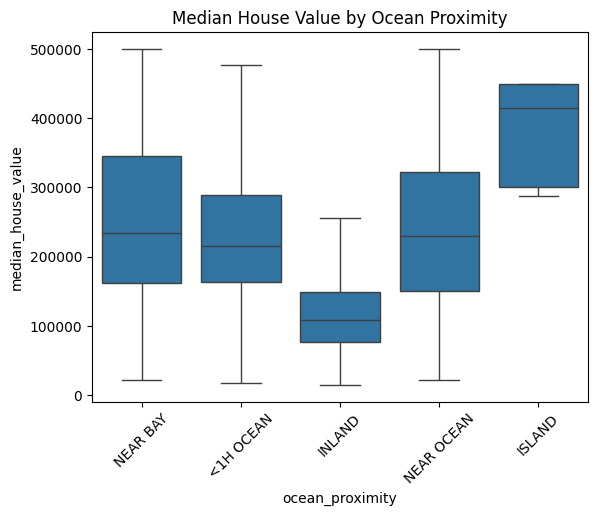

In [15]:
fig7 = sns.boxplot(
    x='ocean_proximity',
    y='median_house_value',
    data=df,
    showfliers=False
)

plt.title("Median House Value by Ocean Proximity")
plt.xticks(rotation=45)
plt.show()


In [17]:
from matplotlib.backends.backend_pdf import PdfPages

with PdfPages("EDA_Report.pdf") as pdf:

    pdf.savefig(fig1)
    pdf.savefig(fig2)
    pdf.savefig(fig3)
    pdf.savefig(fig5)
    pdf.savefig(fig)


print("EDA Report saved successfully.")

EDA Report saved successfully.
